# Task
Perform a Fama-Macbeth regression analysis using the provided 'FF6.csv', 'FF6_Factors.csv', and 'Risk-Free-Cleaned.csv' files to determine the average risk premia for the Fama-French factors and their statistical significance.

In [5]:
import pandas as pd

# 1. Load the datasets
df_ff6 = pd.read_csv('/content/FF6.csv')
df_factors = pd.read_csv('/content/FF6_Factors.csv')
df_rf = pd.read_csv('/content/Risk-Free-Cleaned.csv')

# 2. Convert date columns to datetime and set as index

# For df_ff6: 'month' column has format like 'Apr-14'
df_ff6['month'] = pd.to_datetime(df_ff6['month'], format='%b-%y')
df_ff6 = df_ff6.set_index('month')
df_ff6.index.name = 'Date'

# For df_factors: 'Date' column has format like 'YYYY-MM'
df_factors['Date'] = pd.to_datetime(df_factors['Date'], format='%Y-%m')
df_factors = df_factors.set_index('Date')

# For df_rf: 'month' column has format like 'YYYY-MM'
df_rf['month'] = pd.to_datetime(df_rf['month'], format='%Y-%m')
df_rf = df_rf.set_index('month')
df_rf.index.name = 'Date'

# 3. Merge the datasets
# Merge df_ff6 and df_rf first
df_merged = pd.merge(df_ff6, df_rf, left_index=True, right_index=True, how='inner')

# Then merge the result with df_factors
df_merged = pd.merge(df_merged, df_factors, left_index=True, right_index=True, how='inner')

# 4. Filter the data to include only the period from April 2014 to March 2025
df_merged = df_merged.loc['2014-04-01':'2025-03-31']

print("Data loaded, merged, and filtered successfully. Displaying the first 5 rows:")
print(df_merged.head())
print("\nDisplaying the last 5 rows:")
print(df_merged.tail())
print("\nDataFrame Info:")
df_merged.info()

Data loaded, merged, and filtered successfully. Displaying the first 5 rows:
            Portfolios BV returns (%)  Portfolios BN returns (%)  \
Date                                                               
2014-04-01                        NaN                   0.262471   
2014-05-01                        NaN                  23.102455   
2014-06-01                        NaN                   1.873951   
2014-07-01                        NaN                  -3.014671   
2014-08-01                        NaN                  -2.396891   

            Portfolios BG returns (%)  Portfolios SV returns (%)  \
Date                                                               
2014-04-01                   0.172784                  13.215249   
2014-05-01                   7.275463                  27.552673   
2014-06-01                   7.745938                  18.652457   
2014-07-01                   1.413907                  -7.500655   
2014-08-01                   4.203748 

In [6]:
import pandas as pd

# Identify portfolio return columns
portfolio_cols = [
    'Portfolios BV returns (%)',
    'Portfolios BN returns (%)',
    'Portfolios BG returns (%)',
    'Portfolios SV returns (%)',
    'Portfolios SN returns (%)',
    'Portfolios SG returns (%)'
]

# Identify the risk-free rate column
rf_col = 'RF'

# Calculate excess returns for each portfolio
for col in portfolio_cols:
    new_col_name = col.replace(' returns (%)', ' Excess Returns')
    df_merged[new_col_name] = df_merged[col] - df_merged[rf_col]

print("Excess returns calculated and added to df_merged. Displaying the first 5 rows:")
print(df_merged.head())
print("\nDisplaying the last 5 rows:")
print(df_merged.tail())
print("\nDataFrame Info:")
df_merged.info()

Excess returns calculated and added to df_merged. Displaying the first 5 rows:
            Portfolios BV returns (%)  Portfolios BN returns (%)  \
Date                                                               
2014-04-01                        NaN                   0.262471   
2014-05-01                        NaN                  23.102455   
2014-06-01                        NaN                   1.873951   
2014-07-01                        NaN                  -3.014671   
2014-08-01                        NaN                  -2.396891   

            Portfolios BG returns (%)  Portfolios SV returns (%)  \
Date                                                               
2014-04-01                   0.172784                  13.215249   
2014-05-01                   7.275463                  27.552673   
2014-06-01                   7.745938                  18.652457   
2014-07-01                   1.413907                  -7.500655   
2014-08-01                   4.20374

In [13]:
import statsmodels.api as sm

# Define the Fama-French factors (independent variables) - now SMB, HML, and MF
factors = ['SMB', 'HML', 'MF']

# Define the excess return columns for the portfolios (dependent variables)
excess_return_cols = [
    'Portfolios BV Excess Returns',
    'Portfolios BN Excess Returns',
    'Portfolios BG Excess Returns',
    'Portfolios SV Excess Returns',
    'Portfolios SN Excess Returns',
    'Portfolios SG Excess Returns'
]

# Dictionary to store the betas (factor loadings) for each portfolio
portfolio_betas = {}
portfolio_r_squared = {}
portfolio_alphas = {}
portfolio_mean_residuals = {}

# Perform time-series regressions for each portfolio
for portfolio_excess_return_col in excess_return_cols:
    # Create a temporary DataFrame for regression, dropping NaNs specific to this portfolio
    temp_df = df_merged[[portfolio_excess_return_col] + factors].dropna()

    if not temp_df.empty:
        # Dependent variable (y)
        y = temp_df[portfolio_excess_return_col]
        # Independent variables (X)
        X = sm.add_constant(temp_df[factors]) # Add a constant for the intercept

        # Perform OLS regression
        model = sm.OLS(y, X)
        results = model.fit()

        # Store the coefficients (betas) for the factors and the alpha (constant)
        portfolio_betas[portfolio_excess_return_col] = results.params[factors].to_dict()
        portfolio_r_squared[portfolio_excess_return_col] = results.rsquared
        portfolio_alphas[portfolio_excess_return_col] = results.params['const']
        portfolio_mean_residuals[portfolio_excess_return_col] = results.resid.mean()
    else:
        print(f"Warning: Not enough data for regression for {portfolio_excess_return_col} due to NaNs.")

print("First pass regressions completed. Factor loadings (betas) for each portfolio:")
# Convert the dictionary of betas to a DataFrame for better readability
betas_df = pd.DataFrame(portfolio_betas).T
print(betas_df)
print("\nDataFrame Info for Betas:")
betas_df.info()
print("\nR-squared for each portfolio (First Pass):")
print(pd.Series(portfolio_r_squared))
print("\nAlphas (Intercepts) for each portfolio (First Pass):")
print(pd.Series(portfolio_alphas))
print("\nMean Residuals for each portfolio (First Pass):")
print(pd.Series(portfolio_mean_residuals))

First pass regressions completed. Factor loadings (betas) for each portfolio:
                                   SMB       HML        MF
Portfolios BV Excess Returns -0.423871  1.286465  0.933357
Portfolios BN Excess Returns -0.280698  0.320167  1.064247
Portfolios BG Excess Returns -0.044626 -0.183360  0.994974
Portfolios SV Excess Returns  0.917820  0.815263  0.985479
Portfolios SN Excess Returns  0.712461  0.438499  1.015546
Portfolios SG Excess Returns  0.611040  0.160614  0.937703

DataFrame Info for Betas:
<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, Portfolios BV Excess Returns to Portfolios SG Excess Returns
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMB     6 non-null      float64
 1   HML     6 non-null      float64
 2   MF      6 non-null      float64
dtypes: float64(3)
memory usage: 192.0+ bytes

R-squared for each portfolio (First Pass):
Portfolios BV Excess Returns    0.943494
Portfolios BN Exc

## Second Pass Regressions: Estimating Risk Premia

### Subtask:
Run cross-sectional regressions for each time period to estimate the risk premia for the Fama-French factors.

#### Instructions
1. For each time period (month) in the dataset, perform a cross-sectional regression.
2. The dependent variables for these regressions will be the excess returns of the 6 portfolios for that specific month.
3. The independent variables will be the betas (factor loadings) of the 6 portfolios obtained from the first pass regressions (`betas_df`).
4. Store the estimated coefficients (risk premia) for each factor for each month.
5. Handle missing values appropriately; for cross-sectional regressions, ensure that only portfolios with available excess returns and corresponding betas are included.

**Reasoning**:
I will perform the second pass of the Fama-Macbeth regression by iterating through each month, performing a cross-sectional regression of portfolio excess returns against the previously calculated betas, and storing the monthly risk premia.



In [8]:
import statsmodels.api as sm
import numpy as np

# Prepare the data for the second pass regressions
# Excess returns are already in df_merged
# Betas are in betas_df

# List of excess return columns
excess_return_cols = [
    'Portfolios BV Excess Returns',
    'Portfolios BN Excess Returns',
    'Portfolios BG Excess Returns',
    'Portfolios SV Excess Returns',
    'Portfolios SN Excess Returns',
    'Portfolios SG Excess Returns'
]

# List of factors (which are the independent variables in the first pass,
# and will be the dependent variables' coefficients in the second pass)
factors = ['SMB', 'HML', 'MF']

# DataFrame to store monthly risk premia
monthly_risk_premia = pd.DataFrame(columns=factors, index=df_merged.index.unique())
monthly_r_squared_cs = {}

# Iterate through each month to perform cross-sectional regressions
for date in df_merged.index.unique():
    # Get excess returns for the current month across all portfolios
    R_excess_t = df_merged.loc[date, excess_return_cols]

    # Align excess returns with betas and drop missing values
    # We need to ensure that only portfolios with both valid excess returns AND valid betas are used
    # Since betas_df is indexed by portfolio name, we need to ensure R_excess_t is also aligned.

    # Create a temporary DataFrame to hold betas and current month's excess returns
    temp_cross_section_df = pd.DataFrame({'excess_return': R_excess_t}).join(betas_df, how='inner')

    # Drop rows where excess_return is NaN for the current month
    temp_cross_section_df = temp_cross_section_df.dropna(subset=['excess_return'])

    if not temp_cross_section_df.empty and len(temp_cross_section_df) > len(factors): # Need at least (num_factors + 1) observations
        y_cs = temp_cross_section_df['excess_return']
        X_cs = sm.add_constant(temp_cross_section_df[factors]) # Add a constant to estimate lambda_0 (intercept)

        try:
            model_cs = sm.OLS(y_cs, X_cs)
            results_cs = model_cs.fit()

            # Store the estimated risk premia (coefficients)
            monthly_risk_premia.loc[date, 'const'] = results_cs.params['const'] # Store intercept too if present
            monthly_risk_premia.loc[date, factors] = results_cs.params[factors]
            monthly_r_squared_cs[date] = results_cs.rsquared
        except Exception as e:
            print(f"Regression for {date} failed: {e}")
    else:
        # Fill with NaN if not enough data or regression failed
        monthly_risk_premia.loc[date, 'const'] = np.nan
        monthly_risk_premia.loc[date, factors] = np.nan
        monthly_r_squared_cs[date] = np.nan

print("Second pass regressions completed. Monthly risk premia:")
print(monthly_risk_premia.head())
print("\nDataFrame Info for Monthly Risk Premia:")
monthly_risk_premia.info()
print("\nR-squared for cross-sectional regressions (first 5 months):")
print(pd.Series(monthly_r_squared_cs).head())


Second pass regressions completed. Monthly risk premia:
                  SMB        HML         MF      const
Date                                                  
2014-04-01   3.815057   9.332389 -27.056713  27.049267
2014-05-01   1.608625  18.896709  51.680202 -39.225736
2014-06-01  17.552533  -5.436084  38.890568 -32.987087
2014-07-01   2.017718 -11.197491  -7.904129   8.104935
2014-08-01  11.393204 -15.549489  46.920533 -45.015354

DataFrame Info for Monthly Risk Premia:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132 entries, 2014-04-01 to 2025-03-01
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMB     132 non-null    object 
 1   HML     132 non-null    object 
 2   MF      132 non-null    object 
 3   const   132 non-null    float64
dtypes: float64(1), object(3)
memory usage: 9.2+ KB

R-squared for cross-sectional regressions (first 5 months):
2014-04-01    0.961951
2014-05-01    0.952005
2014-06-01    

**Reasoning**:
The 'monthly_risk_premia' DataFrame contains columns with 'object' dtype which need to be converted to numeric before performing any statistical calculations. I will convert these columns to 'float' to enable mean, standard error, and t-statistic computations.



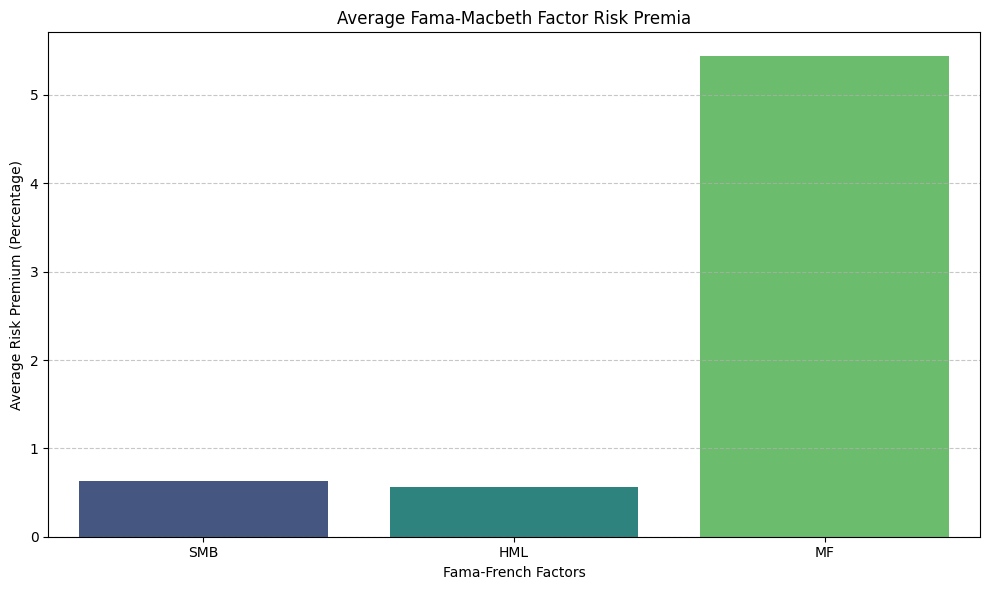

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the results to include only the Fama-French factors (SMB, HML, MF)
# Exclude 'const' as it is the intercept, not a factor risk premium in this context
factor_risk_premia = fama_macbeth_results.loc[['SMB', 'HML', 'MF']]

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=factor_risk_premia.index, y='Average Risk Premium', data=factor_risk_premia, palette='viridis', hue=factor_risk_premia.index, legend=False)

# Add title and labels
plt.title('Average Fama-Macbeth Factor Risk Premia')
plt.xlabel('Fama-French Factors')
plt.ylabel('Average Risk Premium (Percentage)')

# Rotate x-axis labels for better readability if needed (usually not for 4 labels)
plt.xticks(rotation=0)

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
import numpy as np
from scipy import stats

# Convert relevant columns in monthly_risk_premia to numeric (float)
# The 'const' column is already float64, so we only need to convert the factors
for col in factors:
    monthly_risk_premia[col] = pd.to_numeric(monthly_risk_premia[col], errors='coerce')

# Drop any rows that became NaN due to conversion errors, though 'coerce' should handle this
monthly_risk_premia = monthly_risk_premia.dropna()

# 1. Calculate the mean (average) for each factor's risk premium
average_risk_premia = monthly_risk_premia.mean()

# 2. Calculate the standard error of the mean for each factor's risk premium
# Standard error = Standard Deviation / sqrt(N)
standard_errors = monthly_risk_premia.std() / np.sqrt(len(monthly_risk_premia))

# 3. Compute the t-statistic for each factor's average risk premium
t_statistics = average_risk_premia / standard_errors

# 4. Calculate the p-value associated with each t-statistic
# The degrees of freedom is N - 1 for a one-sample t-test
df = len(monthly_risk_premia) - 1
p_values = 2 * (1 - stats.t.cdf(np.abs(t_statistics), df))

# Combine results into a DataFrame for clear presentation
fama_macbeth_results = pd.DataFrame({
    'Average Risk Premium': average_risk_premia,
    'Standard Error': standard_errors,
    't-statistic': t_statistics,
    'p-value': p_values
})

print("Fama-Macbeth Regression Results (Average Risk Premia and Statistical Significance):")
print(fama_macbeth_results)
print("\nDataFrame Info for Fama-Macbeth Results:")
fama_macbeth_results.info()


Fama-Macbeth Regression Results (Average Risk Premia and Statistical Significance):
       Average Risk Premium  Standard Error  t-statistic   p-value
SMB                0.635998        0.422704     1.504595  0.134836
HML                0.568021        0.490421     1.158232  0.248877
MF                 5.436664        1.918638     2.833606  0.005332
const             -4.617456        1.880401    -2.455570  0.015377

DataFrame Info for Fama-Macbeth Results:
<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, SMB to const
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Average Risk Premium  4 non-null      float64
 1   Standard Error        4 non-null      float64
 2   t-statistic           4 non-null      float64
 3   p-value               4 non-null      float64
dtypes: float64(4)
memory usage: 332.0+ bytes


## Summary of R-squared Values

### Subtask:
Calculate and display the average R-squared for the first-pass time-series regressions and the second-pass cross-sectional regressions.

In [10]:
import pandas as pd

# Average R-squared for First Pass (Time-Series Regressions)
average_r_squared_first_pass = pd.Series(portfolio_r_squared).mean()
print(f"Average R-squared for First Pass (Time-Series Regressions): {average_r_squared_first_pass:.4f}")

# Average R-squared for Second Pass (Cross-Sectional Regressions)
average_r_squared_second_pass = pd.Series(monthly_r_squared_cs).mean()
print(f"Average R-squared for Second Pass (Cross-Sectional Regressions): {average_r_squared_second_pass:.4f}")


Average R-squared for First Pass (Time-Series Regressions): 0.9417
Average R-squared for Second Pass (Cross-Sectional Regressions): 0.8682
